### Загрузка данных

In [69]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import LabelEncoder


df_train = pd.read_csv('data.txt')
df_train.head()

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=N
0,50,Self-emp-not-inc,83311.0,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13,United-States,<=N
1,38,Private,215646.0,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40,United-States,<=N
2,53,Private,234721.0,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40,United-States,<=N
3,28,Private,338409.0,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40,Cuba,<=N
4,37,Private,284582.0,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0.0,0.0,40,United-States,<=N


Видно, что у столбцов нет заголовков, исправляем согласно описанию задания

In [70]:
features = [
    'age', 'workclass', 'final_weight', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'cap-gain', 'cap-loss', 'hours-per-week', 'native-country'
]

df_train = pd.read_csv('data.txt', names=features + ['salary'])
df_train.head()

,age,workclass,final_weight,education,education-num,marital-status,occupation,relationship,race,sex,cap-gain,cap-loss,hours-per-week,native-country,salary
0,39,State-gov,77516.0,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40,United-States,<=N
1,50,Self-emp-not-inc,83311.0,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13,United-States,<=N
2,38,Private,215646.0,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40,United-States,<=N
3,53,Private,234721.0,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40,United-States,<=N
4,28,Private,338409.0,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40,Cuba,<=N


### Анализ данных

In [71]:
print(f'Size: {df_train.shape}')
print(df_train.dtypes)

Size: (32573, 15)
age                object
workclass          object
final_weight      float64
education          object
education-num      object
marital-status     object
occupation         object
relationship       object
race               object
sex                object
cap-gain          float64
cap-loss          float64
hours-per-week     object
native-country     object
salary             object
dtype: object


In [72]:
print(df_train.isnull().sum())

age               0
workclass         1
final_weight      1
education         1
education-num     1
marital-status    1
occupation        1
relationship      1
race              1
sex               1
cap-gain          1
cap-loss          1
hours-per-week    1
native-country    1
salary            2
dtype: int64


In [73]:
df_train.describe()

,final_weight,cap-gain,cap-loss
count,3.257200e+04,32572.000000,32572.000000
mean,7.099108e+12,1077.315578,87.226943
std,1.281227e+15,7384.067167,402.917749
min,-4.214100e+04,-1.000000,-444.000000
25%,1.177890e+05,0.000000,0.000000
50%,1.783485e+05,0.000000,0.000000
75%,2.370065e+05,0.000000,0.000000
max,2.312322e+17,99999.000000,4356.000000


salary
<=N    24720
>N      7851
Name: count, dtype: int64


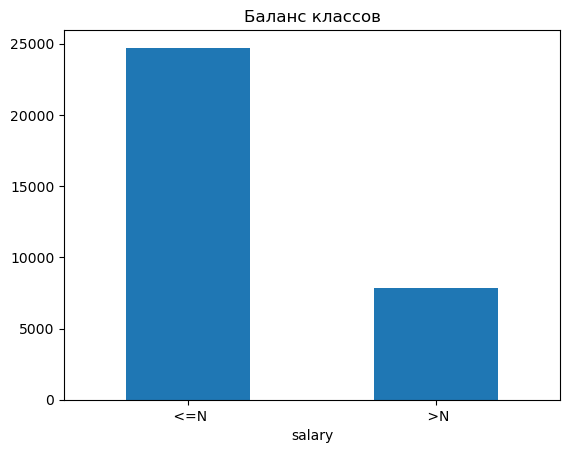

In [74]:
target = 'salary'
print(df_train[target].value_counts())

ax = df_train[target].value_counts().plot(kind='bar')
ax.set_title('Баланс классов')
ax.tick_params(axis='x', rotation=0)
plt.show()